In [4]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report

In [5]:
df = pd.read_csv("Heart_New.csv")

In [6]:
df.head()
df.info()
df.isnull().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB


,0
id,0
age,0
sex,0
dataset,0
cp,0
trestbps,59
chol,30
fbs,90
restecg,2
thalch,55


In [7]:
df["num"].value_counts()

,count
num,
0,411
1,265
2,109
3,107
4,28


In [8]:
df["heart_disease"] = df["num"].apply(lambda x: 1 if x > 0 else 0)
df["heart_disease"].value_counts()

,count
heart_disease,
1,509
0,411


In [9]:
df.groupby("heart_disease")["age"].mean()

,age
heart_disease,
0,50.547445
1,55.903733


In [10]:
df.groupby("heart_disease")["chol"].mean()

,chol
heart_disease,
0,227.905612
1,176.479920


patients without heart disease had higher average cholesterol than patients with heart disease, suggesting the cholesterol column may need closer inspection.

In [11]:
df["chol"].sort_values().head(20)

,chol
819,0.0
822,0.0
818,0.0
785,0.0
783,0.0
784,0.0
812,0.0
781,0.0
787,0.0
774,0.0


In [12]:
(df["chol"] == 0).sum()

np.int64(172)

In [13]:
df["chol"] = df["chol"].replace(0, np.nan)
df["chol"].isnull().sum()

np.int64(202)

In [14]:
df["chol"] = df["chol"].fillna(df["chol"].median())

In [15]:
df["chol"].isnull().sum()

np.int64(0)

We filled missing cholesterol values with the median because the median is less affected by extreme values than the mean.

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 17 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             920 non-null    int64  
 1   age            920 non-null    int64  
 2   sex            920 non-null    object 
 3   dataset        920 non-null    object 
 4   cp             920 non-null    object 
 5   trestbps       861 non-null    float64
 6   chol           920 non-null    float64
 7   fbs            830 non-null    object 
 8   restecg        918 non-null    object 
 9   thalch         865 non-null    float64
 10  exang          865 non-null    object 
 11  oldpeak        858 non-null    float64
 12  slope          611 non-null    object 
 13  ca             309 non-null    float64
 14  thal           434 non-null    object 
 15  num            920 non-null    int64  
 16  heart_disease  920 non-null    int64  
dtypes: float64(5), int64(4), object(8)
memory usage: 122.3

In [17]:
numeric_missing_cols = ["trestbps", "thalch", "oldpeak", "ca"]

for col in numeric_missing_cols:
    df[col] = df[col].fillna(df[col].median())
df[numeric_missing_cols].isnull().sum()

,0
trestbps,0
thalch,0
oldpeak,0
ca,0


Missing numeric values in trestbps, thalch, oldpeak, and ca were filled using the median of each column.


In [18]:
category_missing_cols = ["fbs", "restecg", "exang", "slope", "thal"]

for col in category_missing_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

/tmp/ipykernel_1041/1470934201.py:4: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].fillna(df[col].mode()[0])


In [20]:
df[category_missing_cols].isnull().sum()

,0
fbs,0
restecg,0
exang,0
slope,0
thal,0


In [21]:
df.isnull().sum()

,0
id,0
age,0
sex,0
dataset,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalch,0


In [25]:
X = df.drop(["id", "dataset", "num", "heart_disease"], axis=1)
y = df["heart_disease"]
X.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal
0,63,Male,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect
1,67,Male,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal
2,67,Male,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect
3,37,Male,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal
4,41,Female,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal


In [26]:
X.dtypes

,0
age,int64
sex,object
cp,object
trestbps,float64
chol,float64
fbs,bool
restecg,object
thalch,float64
exang,bool
oldpeak,float64


In [28]:
X_encoded = pd.get_dummies(X, drop_first=True)
X_encoded.head()

,age,trestbps,chol,fbs,thalch,exang,oldpeak,ca,sex_Male,cp_atypical angina,cp_non-anginal,cp_typical angina,restecg_normal,restecg_st-t abnormality,slope_flat,slope_upsloping,thal_normal,thal_reversable defect
0,63,145.0,233.0,True,150.0,False,2.3,0.0,True,False,False,True,False,False,False,False,False,False
1,67,160.0,286.0,False,108.0,True,1.5,3.0,True,False,False,False,False,False,True,False,True,False
2,67,120.0,229.0,False,129.0,True,2.6,2.0,True,False,False,False,False,False,True,False,False,True
3,37,130.0,250.0,False,187.0,False,3.5,0.0,True,False,True,False,True,False,False,False,True,False
4,41,130.0,204.0,False,172.0,False,1.4,0.0,False,True,False,False,False,False,False,True,True,False


In [29]:
X_encoded = X_encoded.astype(float)
X_encoded.head()

,age,trestbps,chol,fbs,thalch,exang,oldpeak,ca,sex_Male,cp_atypical angina,cp_non-anginal,cp_typical angina,restecg_normal,restecg_st-t abnormality,slope_flat,slope_upsloping,thal_normal,thal_reversable defect
0,63.0,145.0,233.0,1.0,150.0,0.0,2.3,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
1,67.0,160.0,286.0,0.0,108.0,1.0,1.5,3.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
2,67.0,120.0,229.0,0.0,129.0,1.0,2.6,2.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
3,37.0,130.0,250.0,0.0,187.0,0.0,3.5,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
4,41.0,130.0,204.0,0.0,172.0,0.0,1.4,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0


In [31]:
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.2,
    random_state=42
)
X_train.shape, X_test.shape

((736, 18), (184, 18))

In [41]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


X_train_scaled[:5]

array([[ 0.90241255, -0.08394637, -1.43582535, -0.40110258, -0.69418678,
         1.32146459,  1.9836244 , -0.36137006,  0.50593744, -0.48252546,
        -0.53335515, -0.23007121, -1.21235253,  2.04526247,  0.67206884,
        -0.55223595,  0.57525841, -0.49745113],
       [ 0.03477619,  0.98777137, -0.09479887, -0.40110258, -0.6149987 ,
        -0.75673613, -0.79440597, -0.36137006,  0.50593744, -0.48252546,
         1.87492331, -0.23007121,  0.82484259, -0.4889348 ,  0.67206884,
        -0.55223595,  0.57525841, -0.49745113],
       [-0.29058745, -0.08394637,  1.82508797, -0.40110258,  0.09769399,
        -0.75673613, -0.33140091, -0.36137006,  0.50593744, -0.48252546,
         1.87492331, -0.23007121,  0.82484259, -0.4889348 ,  0.67206884,
        -0.55223595,  0.57525841, -0.49745113],
       [-0.39904199, -0.61980524, -0.49035344, -0.40110258,  0.81038667,
        -0.75673613,  0.68721023, -0.36137006, -1.97652894, -0.48252546,
         1.87492331, -0.23007121,  0.82484259, -0.488

In [42]:
model = LogisticRegression()

model.fit(X_train_scaled, y_train)

LogisticRegression()

In [44]:
y_pred = model.predict(X_test_scaled)

In [45]:
y_pred[:10]

array([0, 0, 1, 1, 1, 0, 0, 1, 1, 0])

In [46]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

accuracy, precision, recall, f1

(0.8043478260869565,
 0.8476190476190476,
 0.8165137614678899,
 0.8317757009345794)

In [47]:
cm = confusion_matrix(y_test, y_pred)
cm

array([[59, 16],
       [20, 89]])

The confusion matrix shows that the model correctly predicted 59 patients without heart disease and 89 patients with heart disease. It made 16 false positive predictions and 20 false negative predictions. In a healthcare context, the 20 false negatives are especially important because those are patients who actually had heart disease but were predicted as not having it.

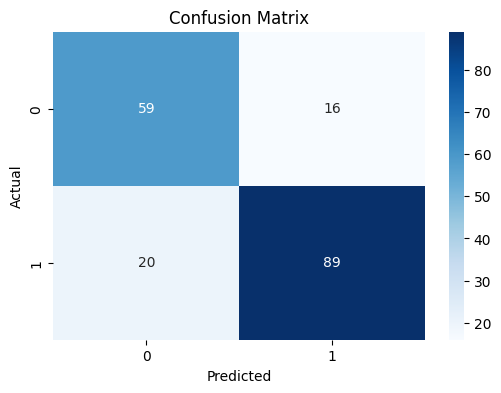

In [48]:
plt.figure(figsize=(6, 4))

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [49]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.75      0.79      0.77        75
           1       0.85      0.82      0.83       109

    accuracy                           0.80       184
   macro avg       0.80      0.80      0.80       184
weighted avg       0.81      0.80      0.81       184



The classification report shows that the logistic regression model performed reasonably well on the test set. The model achieved an overall accuracy of 80%. For patients with heart disease, the model had a precision of 85%, recall of 82%, and F1-score of 83%. Recall is especially important in this project because false negatives mean patients who actually have heart disease were predicted as not having it. The confusion matrix showed 20 false negatives, so although the model performed fairly well, it is not perfect and would need further improvement before being used in a real healthcare setting.


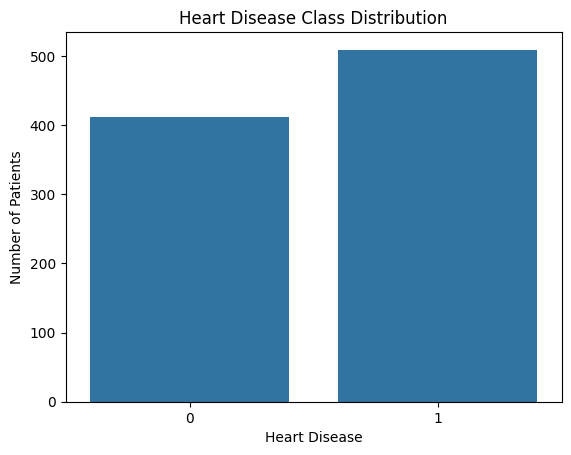

In [50]:
sns.countplot(x="heart_disease", data=df)

plt.title("Heart Disease Class Distribution")
plt.xlabel("Heart Disease")
plt.ylabel("Number of Patients")
plt.show()

This countplot shows the distribution of the target variable. There are slightly more patients with heart disease than without heart disease, but both classes have a large number of examples. This means the dataset is reasonably balanced for training a binary classification model.

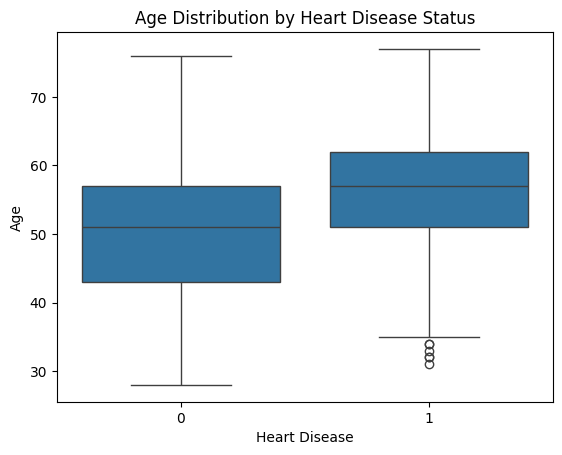

In [51]:
sns.boxplot(x="heart_disease", y="age", data=df)

plt.title("Age Distribution by Heart Disease Status")
plt.xlabel("Heart Disease")
plt.ylabel("Age")
plt.show()

This boxplot compares age between patients with and without heart disease. The median age for patients with heart disease is higher than the median age for patients without heart disease. This suggests that age may be an important feature for predicting heart disease in this dataset.

## Conclusion

In this project, I used the Heart Disease UCI dataset to build a logistic regression model that predicts whether a patient has heart disease. I first explored the dataset, checked for missing values, created a binary target column, and cleaned suspicious values such as cholesterol values recorded as 0. Missing numeric values were filled using the median, while missing categorical values were filled using the mode.

After preprocessing, I removed columns that could cause data leakage, such as `num`, because it was used to create the target variable. I also encoded categorical columns into numeric columns and scaled the features before training the model.

The logistic regression model achieved an accuracy of about 80%, precision of about 85%, recall of about 82%, and an F1-score of about 83% for predicting heart disease. The confusion matrix showed that the model correctly identified many patients with heart disease, but it also missed 20 actual heart disease cases. In a healthcare setting, these false negatives are especially important because missing a patient with heart disease could be dangerous.

Overall, the model performed reasonably well for a beginner machine learning project, but it should not be considered ready for real medical use. Further improvements could include testing other models, tuning hyperparameters, using more medical domain knowledge, and collecting cleaner or more complete data.
